In [ ]:
import marimo as mo

# Task 4 — Improvement Cycle

- Which experiment best reduced hallucinations / unsupported claims?
Experiment 4 reduced grounding failures the most on the manual sample, but the gain was not large enough to justify the extra pipeline overhead.
- Which experiment most improved tone and fluency?
Experiment 3. On the common scored sample it reached 100% good for both tone and fluency, improving on the baseline without giving up grounding discipline.
- Did the best-of-2 pipeline improve quality enough to justify the added latency/cost?
No. Experiment 4 had the best grounding mean on the scored sample, but its mean latency rose to about 5803 ms and total cost to about $0.002711, while Experiment 3 achieved a higher pass rate with roughly half the latency and lower total cost.
- Which experiment is the best trade-off for this assignment?
Experiment 3 is the best overall quality result. Experiment 1 is the simpler prompt-only improvement if the goal is to show a lighter-weight intervention. Experiment 2 is fastest, but its grounding is worse than the baseline, so it is not the best overall trade-off.

## Experiment Log

| # | What changed | Why | Result | Code below? |
|---|-------------|-----|--------|-------------|
| 1 | Rewrote the prompt for a more natural voice and anti-list style (`generation_v3_voice.txt`) | Baseline outputs were often grounded enough to pass, but still sounded like spec lists in prose. | Great results | Yes |
| 2 | Switched to **Qwen3-30B** while keeping the improved voice prompt | Test whether a stronger model follows style + grounding instructions better. | Faster, but grounding regressed on the manual sample, so not the best qualitative result | Yes |
| 3 | Added a hidden narrative scaffold (`generation_v4_scaffold.txt`) | Force a smoother rhetorical flow instead of one-sentence-per-feature writing. | Best overall quality on the manual sample | Yes |
| 4 | Best-of-2 candidate selection with an LLM selector | Try to improve polish by choosing between two grounded candidates instead of accepting the first one. | Slight grounding gain, but too slow and expensive under the rubric | Yes |

In [ ]:
from _bootstrap import bootstrap_notebook

bootstrap_notebook()

import time
import litellm
import mlflow
import pandas as pd
from tqdm import tqdm

from src.artifacts import load_csv_artifact, load_excel_artifact
from src.config import (
    BASELINE_GENERATION_MODEL_ID,
    DEFAULT_FINAL_PROVIDER,
    IMPROVEMENT_GENERATION_MODEL_ID,
    PROMPT_SELECTION_V1,
    PROMPT_VERSION_V3,
    PROMPT_VERSION_V4,
    build_model_config,
    get_force_rerun,
    prompt_path,
)
from src.paths import (
    ASSIGNMENT_XLSX_PATH,
    OUTPUTS_REPORTS_DIR,
    PRODUCTS_CSV_PATH,
    TASK_04_EXPERIMENTS_XLSX_PATH,
)
from src.runtime import load_project_env, read_text, setup_mlflow
from src.task4_export import (
    build_task4_analysis_tables,
    build_task4_summary,
    export_task4_workbook,
    load_task4_experiment_outputs,
)
from src.utils import extract_cost, format_product

load_project_env()
mlflow_db_path = setup_mlflow("improvement_cycle")

In [ ]:
products = pd.read_csv(PRODUCTS_CSV_PATH)
baseline_df = pd.read_excel(ASSIGNMENT_XLSX_PATH)
print(f"Loaded {len(products)} products")
print(f"Baseline workbook: {ASSIGNMENT_XLSX_PATH} ({len(baseline_df)} rows)")
print(f"MLflow tracking DB: {mlflow_db_path}")

Loaded 50 products
Baseline workbook: /Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/w2-ai-product/outputs/assignment_01.xlsx (50 rows)
MLflow tracking DB: /Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/w2-ai-product/outputs/experiments.db


In [ ]:
FORCE_RERUN = get_force_rerun()
if FORCE_RERUN:
    print("FORCE_RERUN=1 — ignoring existing Task 4 experiment artifacts.")

## Shared experiment helpers

Each experiment below logs:
- the generator model
- the prompt version used
- temperatures / candidate counts
- latency and cost metrics

For the best-of-2 experiment, the recorded latency and cost include both candidate generations
and the selector call. This keeps the experiment honest about operational overhead.

In [ ]:
POSITIVE_EXAMPLES: dict[str, str] = {
    "Product: Hydro Flask 32 oz Wide Mouth\nAttributes: features: TempShield insulation, Color Last powder coat; dimensions: compact\nMaterial: pro-grade stainless steel\nWarranty: lifetime warranty": (
        "Stay hydrated on the go with the Hydro Flask 32 oz Wide Mouth. Built from "
        "pro-grade stainless steel, this compact bottle keeps drinks at the right "
        "temperature with TempShield insulation, while the Color Last powder coat helps "
        "maintain its clean finish over time. Its easy-to-carry size makes it a practical "
        "everyday companion, and the lifetime warranty adds extra peace of mind."
    ),
    "Product: Apple iPhone 15 Pro\nAttributes: features: A17 Pro chip, 120 Hz ProMotion display, USB‑C fast charging; dimensions: compact\nMaterial: titanium frame, Ceramic Shield glass\nWarranty: 1‑year limited warranty": (
        "Meet the Apple iPhone 15 Pro, a compact smartphone built around the A17 Pro chip "
        "and a 120 Hz ProMotion display. Its titanium frame and Ceramic Shield glass give "
        "it a distinctly premium construction, while USB‑C fast charging adds a modern "
        "convenience. The package is backed by a 1‑year limited warranty."
    ),
}
CONTRASTIVE_BAD_EXAMPLE = "Stanley Quencher H2.0 40 oz"
OBSERVED_FAILURE_EXAMPLE = "PlayStation 5 Slim"

In [ ]:
if POSITIVE_EXAMPLES:
    print(
        f"Loaded {len(POSITIVE_EXAMPLES)} positive example(s) from POSITIVE_EXAMPLES."
    )
else:
    print("POSITIVE_EXAMPLES is empty. Running without injected good examples.")

positive_example_names = "; ".join(
    product_info.splitlines()[0].removeprefix("Product: ").strip()
    for product_info in POSITIVE_EXAMPLES
)

def compose_prompt(base_prompt: str) -> str:
    if not POSITIVE_EXAMPLES:
        return base_prompt

    rendered_examples = "\n\n".join(
        f"### Example {index}\n{product_info.strip()}\n\nDescription:\n{description.strip()}"
        for index, (product_info, description) in enumerate(
            POSITIVE_EXAMPLES.items(), start=1
        )
    )
    return f"{base_prompt.rstrip()}\n\n## Good examples to imitate\n\n{rendered_examples}"

Loaded 2 positive example(s) from POSITIVE_EXAMPLES.


In [ ]:
task4_artifacts_dir = OUTPUTS_REPORTS_DIR / "task_04_experiments"
task4_artifacts_dir.mkdir(parents=True, exist_ok=True)

generation_required_columns = [
    "product_name",
    "generated_description",
    "latency_ms",
    "input_tokens",
    "output_tokens",
    "cost_usd",
]

def experiment_table_path(run_name: str):
    return task4_artifacts_dir / f"{run_name}.csv"

def load_existing_experiment_table(
    run_name: str,
    required_columns: list[str],
) -> pd.DataFrame | None:
    if FORCE_RERUN:
        return None
    return load_csv_artifact(
        experiment_table_path(run_name),
        required_columns=required_columns,
    )

def persist_experiment_table(
    df_result: pd.DataFrame, run_name: str
) -> tuple[str, str]:
    table_path = experiment_table_path(run_name)
    df_result.to_csv(table_path, index=False)
    active_run = mlflow.active_run()
    run_id = active_run.info.run_id if active_run else ""
    if active_run:
        mlflow.log_artifact(str(table_path), artifact_path="task_04_tables")
    return run_id, str(table_path)

def generate_description(
    product: dict, model: str, system_prompt: str, temperature: float
) -> dict:
    start = time.perf_counter_ns()
    response = litellm.completion(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": format_product(product)},
        ],
        temperature=temperature,
        max_tokens=200,
    )
    latency_ms = (time.perf_counter_ns() - start) / 1e6
    input_tokens = response.usage.prompt_tokens
    output_tokens = response.usage.completion_tokens
    cost_usd = extract_cost(response, input_tokens, output_tokens)
    return {
        "generated_description": response.choices[0].message.content.strip(),
        "latency_ms": round(latency_ms, 1),
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "cost_usd": round(cost_usd, 8),
    }

def run_generation_experiment(
    *,
    products: pd.DataFrame,
    run_name: str,
    model: str,
    system_prompt: str,
    temperature: float,
    desc: str,
    params: dict,
) -> tuple[pd.DataFrame, str, str]:
    existing_df = load_existing_experiment_table(
        run_name,
        generation_required_columns,
    )
    table_path = experiment_table_path(run_name)
    if existing_df is not None:
        print(f"Source: loaded existing artifact {table_path}")
        return existing_df.copy(), "", str(table_path)

    print(
        f"Source: artifact missing or invalid, running live experiment -> {table_path}"
    )
    rows = []
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        for _, row in tqdm(products.iterrows(), total=len(products), desc=desc):
            result = generate_description(
                row.to_dict(), model, system_prompt, temperature
            )
            rows.append(
                {
                    "product_name": row["product_name"],
                    **result,
                }
            )

        df_result = pd.DataFrame(rows)
        mlflow.log_metrics(
            {
                "mean_latency_ms": df_result["latency_ms"].mean(),
                "total_cost_usd": df_result["cost_usd"].sum(),
                "mean_input_tokens": df_result["input_tokens"].mean(),
                "mean_output_tokens": df_result["output_tokens"].mean(),
            }
        )
        run_id, table_path = persist_experiment_table(df_result, run_name)
    return df_result, run_id, table_path

def choose_candidate(
    *,
    product: dict,
    candidate_a: str,
    candidate_b: str,
    selector_model: str,
    selector_prompt: str,
) -> dict:
    start = time.perf_counter_ns()
    selector_response = litellm.completion(
        model=selector_model,
        messages=[
            {"role": "system", "content": selector_prompt},
            {
                "role": "user",
                "content": (
                    f"## Original Product Data\n{format_product(product)}\n\n"
                    f"## Candidate A\n{candidate_a}\n\n"
                    f"## Candidate B\n{candidate_b}"
                ),
            },
        ],
        temperature=0.0,
        max_tokens=4,
    )
    latency_ms = (time.perf_counter_ns() - start) / 1e6
    raw_choice = selector_response.choices[0].message.content.strip().upper()
    parsed_choice = (
        "A"
        if raw_choice.startswith("A")
        else "B"
        if raw_choice.startswith("B")
        else "A"
    )
    input_tokens = selector_response.usage.prompt_tokens
    output_tokens = selector_response.usage.completion_tokens
    cost_usd = extract_cost(selector_response, input_tokens, output_tokens)
    return {
        "choice": parsed_choice,
        "selector_raw": raw_choice,
        "selector_latency_ms": round(latency_ms, 1),
        "selector_input_tokens": input_tokens,
        "selector_output_tokens": output_tokens,
        "selector_cost_usd": round(cost_usd, 8),
    }

## Experiment 1 — Voice prompt rewrite (`generation_v3_voice.txt`)

**What changed:**
- Added explicit anti-listiness instructions
- Injected 2 positive examples, and a contrastive bad example
- Added a stronger grounding warning against plausible-but-unsupported claims

**Why expected to help:**
The baseline already writes grammatical copy, but it often reads like a feature sheet converted into sentences. This prompt tries to keep only the most relevant details and make the prose feel more like real e-commerce copy.

In [ ]:
prompt_v3 = compose_prompt(read_text(prompt_path(PROMPT_VERSION_V3)))

In [ ]:
df_exp1, exp1_run_id, exp1_table_path = run_generation_experiment(
    products=products,
    run_name="exp1_llama8b_prompt_v3_voice",
    model=build_model_config(
        DEFAULT_FINAL_PROVIDER, BASELINE_GENERATION_MODEL_ID
    ).model,
    system_prompt=prompt_v3,
    temperature=0.3,
    desc="Exp 1: voice prompt v3",
    params={
        "experiment_id": "exp1_voice_prompt_rewrite",
        "generator_model": BASELINE_GENERATION_MODEL_ID,
        "generator_provider": DEFAULT_FINAL_PROVIDER,
        "prompt_version": PROMPT_VERSION_V3,
        "positive_examples_enabled": bool(POSITIVE_EXAMPLES),
        "positive_examples_count": len(POSITIVE_EXAMPLES),
        "positive_example_names": positive_example_names,
        "temperature": 0.3,
        "max_tokens": 200,
        "contrastive_bad_example": CONTRASTIVE_BAD_EXAMPLE,
        "observed_failure_example": OBSERVED_FAILURE_EXAMPLE,
        "targeted_weaknesses": "grounding,fluency,tone",
    },
)
df_exp1.head(3)

Source: loaded existing artifact /Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/w2-ai-product/outputs/reports/task_04_experiments/exp1_llama8b_prompt_v3_voice.csv


,product_name,generated_description,latency_ms,input_tokens,output_tokens,cost_usd
0,Apple iPhone 15 Pro,"Meet the Apple iPhone 15 Pro, a compact powerhouse driven by the A17 Pro chip. Its 120 Hz ProMotion display delivers seamless visuals, while USB-C fast charging gets you back to full speed quickly. The premium construction features a durable titanium frame and shatter-resistant Ceramic Shield glass, making it a reliable companion for everyday use.",3436.9,804,69,0.000020
1,Samsung Galaxy S24 Ultra,"Capture life's moments with the Samsung Galaxy S24 Ultra. This powerful smartphone boasts a 200 MP camera, perfect for capturing stunning detail and vibrant colors. The S‑Pen support lets you take notes and create with precision, while the 120 Hz AMOLED display provides a seamless viewing experience. Built with a sustainably sourced design and a durable Armor Aluminum frame, this phone is both eco-friendly and built to last. Enjoy a 1‑year limited warranty, giving you peace of mind.",2997.2,807,103,0.000022
2,Google Pixel 8 Pro,"Capture life's moments with the Google Pixel 8 Pro. Powered by the Tensor G3 chip, this smartphone delivers seamless performance and a 4.7/5-star rating from satisfied users. Its 50 MP camera is paired with Magic Eraser, a feature that helps you edit out unwanted objects from your photos. The device's durable design features a matte glass back and aluminum frame, and it's backed by a 1-year limited warranty.",2645.6,805,91,0.000022


## Experiment 2 — Larger model with the same voice prompt

**What changed:**
- Kept `generation_v3_voice.txt`
- Swapped the generator from Llama-3.1-8B to `Qwen/Qwen3-30B-A3B-Instruct-2507`

**Why expected to help:**
This isolates the model-capability variable after the prompt rewrite. If the stronger model improves results, we can attribute the gain to better instruction following and stronger text quality rather than to prompt changes alone.

In [ ]:
model_qwen = build_model_config(
    DEFAULT_FINAL_PROVIDER, IMPROVEMENT_GENERATION_MODEL_ID
).model
df_exp2, exp2_run_id, exp2_table_path = run_generation_experiment(
    products=products,
    run_name="exp2_qwen30b_prompt_v3_voice",
    model=model_qwen,
    system_prompt=prompt_v3,
    temperature=0.3,
    desc="Exp 2: Qwen30B + voice prompt v3",
    params={
        "experiment_id": "exp2_larger_model_same_prompt",
        "generator_model": IMPROVEMENT_GENERATION_MODEL_ID,
        "generator_provider": DEFAULT_FINAL_PROVIDER,
        "prompt_version": "generation_v3_voice",
        "positive_examples_enabled": bool(POSITIVE_EXAMPLES),
        "positive_examples_count": len(POSITIVE_EXAMPLES),
        "positive_example_names": positive_example_names,
        "temperature": 0.3,
        "max_tokens": 200,
        "contrastive_bad_example": CONTRASTIVE_BAD_EXAMPLE,
        "observed_failure_example": OBSERVED_FAILURE_EXAMPLE,
        "targeted_weaknesses": "grounding,fluency,tone",
    },
)
df_exp2.head(3)

Source: loaded existing artifact /Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/w2-ai-product/outputs/reports/task_04_experiments/exp2_qwen30b_prompt_v3_voice.csv


,product_name,generated_description,latency_ms,input_tokens,output_tokens,cost_usd
0,Apple iPhone 15 Pro,"Meet the Apple iPhone 15 Pro, a compact powerhouse built for performance and precision. At its core is the A17 Pro chip, delivering lightning-fast speed and efficiency, while the 120 Hz ProMotion display ensures smooth, responsive visuals. The sleek titanium frame combines strength with lightweight durability, and Ceramic Shield glass offers exceptional drop protection. With USB-C fast charging, power is always within reach. Backed by a 1-year limited warranty, this premium device is designed to keep up with your life.",1233.5,821,106,0.000023
1,Samsung Galaxy S24 Ultra,"Capture every detail with the Samsung Galaxy S24 Ultra, featuring a stunning 200 MP camera and seamless S-Pen support for creative control. Its 120 Hz AMOLED display delivers smooth, vibrant visuals, while the durable Armor Aluminum frame and Gorilla Glass Victus protect against daily wear. Built with sustainably sourced materials, this powerful smartphone combines premium design and performance, backed by a 1-year limited warranty.",1085.5,826,90,0.000022
2,Google Pixel 8 Pro,"Capture every detail with the Google Pixel 8 Pro, featuring a powerful Tensor G3 chip and a 50 MP camera that delivers stunning photos. The Magic Eraser tool makes editing effortless, letting you remove unwanted elements with just a tap. Designed with a sleek matte glass back and an aluminum frame, it feels premium in hand. With a 4.7/5 customer rating and a 1-year limited warranty, it’s a reliable choice for everyday excellence.",1427.5,819,95,0.000022


## Experiment 3 — Narrative scaffold prompt (`generation_v4_scaffold.txt`)

**What changed:**
- Kept the same runtime positive examples as Experiment 1
- Added a hidden rhetorical structure:
  1. main appeal
  2. 2–3 grounded details
  3. brief reassuring close

**Why expected to help:**
The baseline often puts one feature in each sentence. A light internal structure should produce smoother rhythm without forcing visible formatting into the output.

In [ ]:
prompt_v4 = compose_prompt(read_text(prompt_path(PROMPT_VERSION_V4)))
df_exp3, exp3_run_id, exp3_table_path = run_generation_experiment(
    products=products,
    run_name="exp3_llama8b_prompt_v4_scaffold",
    model=build_model_config(
        DEFAULT_FINAL_PROVIDER, BASELINE_GENERATION_MODEL_ID
    ).model,
    system_prompt=prompt_v4,
    temperature=0.3,
    desc="Exp 3: scaffold prompt v4",
    params={
        "experiment_id": "exp3_narrative_scaffold_prompt",
        "generator_model": BASELINE_GENERATION_MODEL_ID,
        "generator_provider": DEFAULT_FINAL_PROVIDER,
        "prompt_version": PROMPT_VERSION_V4,
        "positive_examples_enabled": bool(POSITIVE_EXAMPLES),
        "positive_examples_count": len(POSITIVE_EXAMPLES),
        "positive_example_names": positive_example_names,
        "temperature": 0.3,
        "max_tokens": 200,
        "contrastive_bad_example": CONTRASTIVE_BAD_EXAMPLE,
        "observed_failure_example": OBSERVED_FAILURE_EXAMPLE,
        "targeted_weaknesses": "grounding,fluency,tone",
    },
)
df_exp3.head(3)

Source: loaded existing artifact /Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/w2-ai-product/outputs/reports/task_04_experiments/exp3_llama8b_prompt_v4_scaffold.csv


,product_name,generated_description,latency_ms,input_tokens,output_tokens,cost_usd
0,Apple iPhone 15 Pro,"Meet the Apple iPhone 15 Pro, a compact smartphone built around the A17 Pro chip and a 120 Hz ProMotion display. Its titanium frame and Ceramic Shield glass give it a distinctly premium construction, while USB-C fast charging adds a modern convenience. The iPhone 15 Pro is a sleek and powerful device that's ready to take on your daily life.",2203.6,870,73,0.000022
1,Samsung Galaxy S24 Ultra,"Capture life's moments with the Samsung Galaxy S24 Ultra. This powerhouse smartphone boasts an impressive 200 MP camera, perfect for capturing stunning photos and videos. The S-Pen support lets you take notes, draw, and navigate with precision. The 120 Hz AMOLED display provides a seamless viewing experience. Built with a durable Armor Aluminum frame and Gorilla Glass Victus, this device is designed to withstand daily use. Backed by a 1-year limited warranty, you can trust it to keep up with your active lifestyle.",3966.7,873,108,0.000024
2,Google Pixel 8 Pro,"Capture life's moments with the Google Pixel 8 Pro. This flagship smartphone is powered by the Tensor G3 chip, delivering seamless performance and efficient battery life. The 50 MP camera takes stunning photos, while the Magic Eraser feature helps remove unwanted objects from your shots. The device's durable construction features a matte glass back and aluminum frame. With a 4.7/5 rating, you can trust the Pixel 8 Pro to deliver exceptional quality and performance, backed by a 1‑year limited warranty.",2981.3,871,106,0.000024


## Experiment 4 — Best-of-2 candidate selection

**What changed:**
- Generated two candidates per product with the `generation_v4_scaffold.txt` prompt
- Used a separate selector prompt to choose between Candidate A and Candidate B
- Counted the cost and latency of both generation calls plus the selector call

**Why expected to help:**
If one candidate is slightly more natural or safer than the other, we may be able to improve final output quality through reranking without changing the prompt again.

In [ ]:
exp4_csv_path = experiment_table_path("exp4_llama8b_prompt_v4_best_of_2")
exp4_required_columns = generation_required_columns + [
    "candidate_a_description",
    "candidate_b_description",
    "selector_choice",
    "selector_raw",
]
df_exp4_existing = None
if not FORCE_RERUN:
    df_exp4_existing = load_csv_artifact(
        exp4_csv_path,
        required_columns=exp4_required_columns,
    )

if df_exp4_existing is not None:
    print(f"Source: loaded existing artifact {exp4_csv_path}")
    exp4_preview = df_exp4_existing.head(3)
else:
    print(
        f"Source: artifact missing or invalid, running live experiment -> {exp4_csv_path}"
    )
    generator_model = build_model_config(
        DEFAULT_FINAL_PROVIDER, BASELINE_GENERATION_MODEL_ID
    ).model
    selector_model = build_model_config(
        DEFAULT_FINAL_PROVIDER, IMPROVEMENT_GENERATION_MODEL_ID
    ).model
    selector_prompt = read_text(prompt_path(PROMPT_SELECTION_V1))

    rows = []
    with mlflow.start_run(run_name="exp4_llama8b_prompt_v4_best_of_2"):
        mlflow.log_params(
            {
                "experiment_id": "exp4_best_of_2_selection",
                "generator_model": BASELINE_GENERATION_MODEL_ID,
                "generator_provider": DEFAULT_FINAL_PROVIDER,
                "prompt_version": "generation_v4_scaffold",
                "positive_examples_enabled": bool(POSITIVE_EXAMPLES),
                "positive_examples_count": len(POSITIVE_EXAMPLES),
                "positive_example_names": positive_example_names,
                "selection_prompt_version": PROMPT_SELECTION_V1,
                "selector_model": IMPROVEMENT_GENERATION_MODEL_ID,
                "selector_provider": DEFAULT_FINAL_PROVIDER,
                "candidate_a_temperature": 0.2,
                "candidate_b_temperature": 0.5,
                "selector_temperature": 0.0,
                "candidates_per_product": 2,
                "max_tokens": 200,
                "selection_policy": "grounding_first_then_fluency_tone",
                "contrastive_bad_example": CONTRASTIVE_BAD_EXAMPLE,
                "observed_failure_example": OBSERVED_FAILURE_EXAMPLE,
            }
        )

        for _, row in tqdm(
            products.iterrows(), total=len(products), desc="Exp 4: best-of-2"
        ):
            product = row.to_dict()
            candidate_a = generate_description(
                product, generator_model, prompt_v4, 0.2
            )
            candidate_b = generate_description(
                product, generator_model, prompt_v4, 0.5
            )
            selection = choose_candidate(
                product=product,
                candidate_a=candidate_a["generated_description"],
                candidate_b=candidate_b["generated_description"],
                selector_model=selector_model,
                selector_prompt=selector_prompt,
            )
            chosen = candidate_a if selection["choice"] == "A" else candidate_b
            rows.append(
                {
                    "product_name": row["product_name"],
                    "generated_description": chosen["generated_description"],
                    "latency_ms": round(
                        candidate_a["latency_ms"]
                        + candidate_b["latency_ms"]
                        + selection["selector_latency_ms"],
                        1,
                    ),
                    "input_tokens": (
                        candidate_a["input_tokens"]
                        + candidate_b["input_tokens"]
                        + selection["selector_input_tokens"]
                    ),
                    "output_tokens": (
                        candidate_a["output_tokens"]
                        + candidate_b["output_tokens"]
                        + selection["selector_output_tokens"]
                    ),
                    "cost_usd": round(
                        candidate_a["cost_usd"]
                        + candidate_b["cost_usd"]
                        + selection["selector_cost_usd"],
                        8,
                    ),
                    "candidate_a_description": candidate_a["generated_description"],
                    "candidate_b_description": candidate_b["generated_description"],
                    "selector_choice": selection["choice"],
                    "selector_raw": selection["selector_raw"],
                }
            )

        df_exp4 = pd.DataFrame(rows)
        mlflow.log_metrics(
            {
                "mean_latency_ms": df_exp4["latency_ms"].mean(),
                "total_cost_usd": df_exp4["cost_usd"].sum(),
                "mean_input_tokens": df_exp4["input_tokens"].mean(),
                "mean_output_tokens": df_exp4["output_tokens"].mean(),
                "selector_choice_a_rate": (
                    df_exp4["selector_choice"] == "A"
                ).mean(),
                "selector_choice_b_rate": (
                    df_exp4["selector_choice"] == "B"
                ).mean(),
            }
        )
        persist_experiment_table(df_exp4, "exp4_llama8b_prompt_v4_best_of_2")
    exp4_preview = df_exp4.head(3)

exp4_preview

Source: loaded existing artifact /Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/w2-ai-product/outputs/reports/task_04_experiments/exp4_llama8b_prompt_v4_best_of_2.csv


,product_name,generated_description,latency_ms,input_tokens,output_tokens,cost_usd,candidate_a_description,candidate_b_description,selector_choice,selector_raw
0,Apple iPhone 15 Pro,"Stay ahead of the curve with the Apple iPhone 15 Pro. This compact smartphone packs a powerful punch with the A17 Pro chip and a 120 Hz ProMotion display, delivering seamless performance and stunning visuals. Its premium construction features a durable titanium frame and scratch-resistant Ceramic Shield glass, while USB-C fast charging gets you back to full speed in no time. Backed by a 1-year limited warranty.",3947.8,2116,149,0.000051,"Meet the Apple iPhone 15 Pro, a compact smartphone built around the A17 Pro chip and a 120 Hz ProMotion display. Its titanium frame and Ceramic Shield glass give it a distinctly premium construction, while USB-C fast charging adds a modern convenience. The package is backed by a 1-year limited warranty.","Stay ahead of the curve with the Apple iPhone 15 Pro. This compact smartphone packs a powerful punch with the A17 Pro chip and a 120 Hz ProMotion display, delivering seamless performance and stunning visuals. Its premium construction features a durable titanium frame and scratch-resistant Ceramic Shield glass, while USB-C fast charging gets you back to full speed in no time. Backed by a 1-year limited warranty.",B,B
1,Samsung Galaxy S24 Ultra,"Elevate your mobile experience with the Samsung Galaxy S24 Ultra. This powerhouse device boasts a 200 MP camera, perfect for capturing life's moments in stunning detail, while the S-Pen support enables intuitive note-taking and creative expression. The 120 Hz AMOLED display delivers seamless visuals, and the sustainably sourced design ensures a clear conscience. The durable Armor Aluminum frame and Gorilla Glass Victus provide a robust build, all backed by a 1-year limited warranty.",7815.9,2178,198,0.000055,"Capture life's moments with precision and style using the Samsung Galaxy S24 Ultra. This flagship smartphone boasts a 200 MP camera, perfect for capturing stunning details, while the S‑Pen support lets you take notes and create with ease. The 120 Hz AMOLED display offers a seamless viewing experience. Built with a durable Armor Aluminum frame and Gorilla Glass Victus, this device is designed to withstand daily wear and tear, and is backed by a 1-year limited warranty.","Elevate your mobile experience with the Samsung Galaxy S24 Ultra. This powerhouse device boasts a 200 MP camera, perfect for capturing life's moments in stunning detail, while the S-Pen support enables intuitive note-taking and creative expression. The 120 Hz AMOLED display delivers seamless visuals, and the sustainably sourced design ensures a clear conscience. The durable Armor Aluminum frame and Gorilla Glass Victus provide a robust build, all backed by a 1-year limited warranty.",B,B
2,Google Pixel 8 Pro,"Capture life's moments with the Google Pixel 8 Pro. Powered by the Tensor G3 chip, this smartphone delivers seamless performance, while the 50 MP camera ensures stunning photos and video. Plus, the Magic Eraser feature helps remove unwanted objects from your shots. With a durable design featuring a matte glass back and aluminum frame, you can trust this phone to withstand daily use. Backed by a 1‑year limited warranty, the Pixel 8 Pro is a reliable choice for anyone seeking a high-quality mobile experience.",6261.0,2158,195,0.000055,"Capture life's moments with the Google Pixel 8 Pro. This flagship smartphone is powered by the Tensor G3 chip, delivering seamless performance and efficient battery life. The 50 MP camera lets you capture stunning photos, while the Magic Eraser feature helps you remove unwanted objects from your shots. The phone's durable design features a matte glass back and aluminum frame, and is backed by a 1‑year limited warranty.","Capture life's moments with the Google Pixel 8 Pro. Powered by the Tensor G3 chip, this smartphone delivers seamless performance, while the 50 MP came

In [ ]:
experiment_outputs = load_task4_experiment_outputs(task4_artifacts_dir)

In [ ]:
workbook_required_columns = [
    "experiment_key",
    "experiment_label",
    "product_name",
    "generated_description",
    "final_score",
]
task4_experiments_df = None
if not FORCE_RERUN:
    task4_experiments_df = load_excel_artifact(
        TASK_04_EXPERIMENTS_XLSX_PATH,
        required_columns=workbook_required_columns,
        sheet_name="experiments",
    )

if task4_experiments_df is not None:
    print(f"Source: loaded existing artifact {TASK_04_EXPERIMENTS_XLSX_PATH}")
    task4_summary = build_task4_summary(task4_experiments_df)
else:
    task4_workbook_path, task4_experiments_df, task4_summary = (
        export_task4_workbook(
            baseline_df=baseline_df,
            experiment_outputs=experiment_outputs,
            products=products,
        )
    )
    print(f"Task 4 workbook written: {task4_workbook_path}")

Source: loaded existing artifact /Users/zakhar/Documents/code/learning-ai-nebius-ai-engineering-2026/w2-ai-product/outputs/task_04_experiments.xlsx


In [ ]:
criterion_score_df, failure_attribution_df = build_task4_analysis_tables(
    task4_experiments_df
)

notes_by_experiment = {
    "Baseline": "Baseline",
    "Exp 1": "Voice rewrite improves style while staying fast enough.",
    "Exp 2": "Stronger model, but latency penalties dominate the official score.",
    "Exp 3": "Narrative scaffold improves style with better speed than Exp 2.",
    "Exp 4": "Selector pipeline is too slow/expensive under the official rubric.",
}
comparison_df = task4_summary.copy()
comparison_df["Scored sample"] = comparison_df.apply(
    lambda row: f"{int(row['n_scored'])}/{int(row['comparison_rows'])}", axis=1
)
comparison_df["Pass rate"] = comparison_df["pass_rate"].map(
    lambda value: "—" if pd.isna(value) else f"{value:.1%}"
)
comparison_df["Mean latency (ms)"] = (
    comparison_df["mean_latency_ms"].round(0).astype(int)
)
comparison_df["Total cost ($)"] = comparison_df["total_cost_usd"].map(
    lambda value: f"{value:.6f}"
)
comparison_df["Notes"] = comparison_df["experiment"].map(notes_by_experiment)
comparison_df = comparison_df.rename(
    columns={
        "experiment": "Experiment",
        "generator": "Generator",
        "prompt_or_policy": "Prompt / Selection",
    }
)

def _format_score(value: float) -> str:
    if pd.isna(value):
        return "—"
    blocks = "█" * int(round(value * 8))
    return f"{value:.0%} {blocks}".strip()

criterion_heatmap_df = criterion_score_df.copy()
for col in criterion_heatmap_df.columns[1:]:
    criterion_heatmap_df[col] = criterion_heatmap_df[col].map(_format_score)

In [ ]:
mo.md("## Comparison")
mo.md(
    "Official pass rate includes all seven criteria, including latency and cost. "
    "The tables below keep that canonical score, then separate out why experiments fail."
)
mo.ui.table(
    comparison_df[
        [
            "Experiment",
            "Generator",
            "Pass rate",
            "Prompt / Selection",
            "Mean latency (ms)",
            "Total cost ($)",
        ]
    ],
    label="Task 4 comparison on the common manual sample",
)

,_marimo_row_id,Experiment,Generator,Pass rate,Prompt / Selection,Mean latency (ms),Total cost ($)
0,0,Baseline,Llama-3.1-8B,56.2%,generation_v1,4040,0.000517
1,1,Exp 1,Llama-3.1-8B,75.0%,generation_v3_voice,3201,0.001074
2,2,Exp 2,Qwen3-30B,50.0%,generation_v3_voice,1044,0.001110
3,3,Exp 3,Llama-3.1-8B,81.2%,generation_v4_scaffold,3052,0.001144
4,4,Exp 4,Llama-3.1-8B + selector,31.2%,generation_v4_scaffold + generation_selector_v1,5803,0.002711


In [ ]:
mo.md("## Criterion score matrix")
mo.md(
    "Average rubric score on the scored comparison sample, where good=100%, ok=50%, bad=0%."
)
mo.ui.table(
    criterion_heatmap_df,
    label="Heatmap-style criterion averages across the common sample",
)

,_marimo_row_id,Experiment,Fluency,Grammar,Tone,Length,Grounding,Latency,Cost,Pass rate
0,0,Baseline,91% ███████,97% ████████,94% ████████,100% ████████,38% ███,38% ███,100% ████████,56% ████
1,1,Exp 1,94% ████████,100% ████████,100% ████████,100% ████████,41% ███,44% ████,100% ████████,75% ██████
2,2,Exp 2,97% ████████,100% ████████,100% ████████,94% ████████,25% ██,100% ████████,100% ████████,50% ████
3,3,Exp 3,100% ████████,100% ████████,100% ████████,97% ████████,41% ███,50% ████,100% ████████,81% ██████
4,4,Exp 4,97% ████████,100% ████████,100% ████████,100% ████████,44% ████,16% █,100% ████████,31% ██


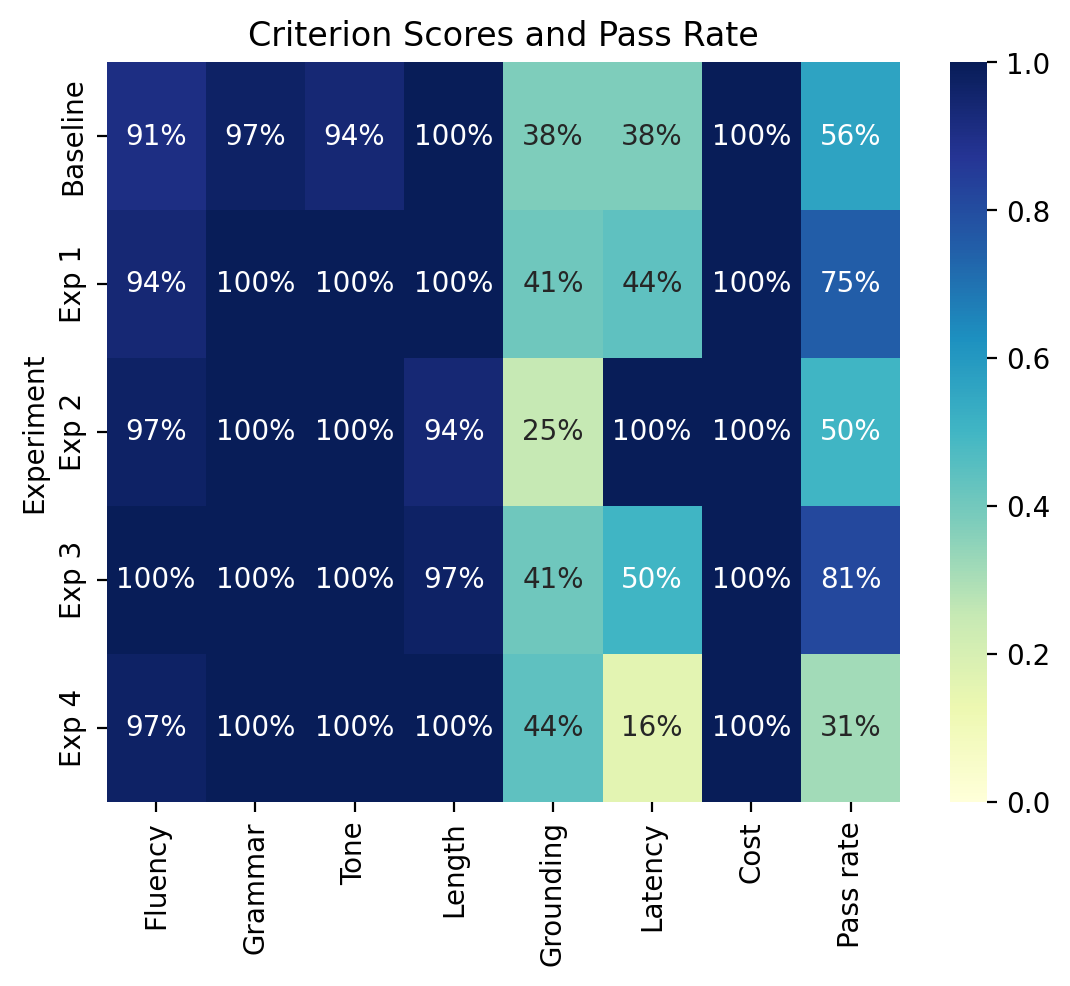

In [ ]:
import seaborn as sns

def _(criterion_score_df, failure_attribution_df, pd, sns):
    criterion_plot_df = criterion_score_df.set_index("Experiment")
    criterion_annot_df = criterion_plot_df.map(
        lambda v: "—" if pd.isna(v) else f"{v:.0%}"
    )

    criterion_ax = sns.heatmap(
        criterion_plot_df,
        annot=criterion_annot_df,
        fmt="",
        cmap="YlGnBu",
        vmin=0,
        vmax=1,
    )
    criterion_ax.set_title("Criterion Scores and Pass Rate")
    criterion_fig = criterion_ax.figure
    criterion_fig

    return criterion_fig

_(criterion_score_df, failure_attribution_df, pd, sns)

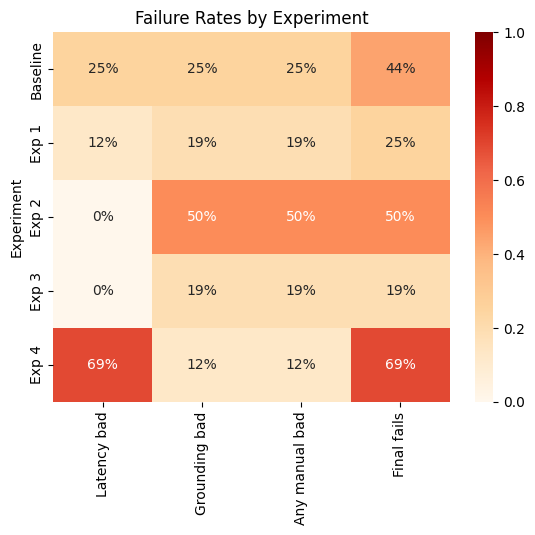

In [ ]:

def _(failure_attribution_df, mo, pd, sns):
    failure_rate_df = failure_attribution_df.copy()

    scored_counts = (
        failure_rate_df["Scored sample"].str.split("/").str[0].astype(int)
    )

    rate_cols = ["Latency bad", "Grounding bad", "Any manual bad", "Final fails"]
    for col in rate_cols:
        failure_rate_df[col] = failure_rate_df[col] / scored_counts

    failure_rate_plot_df = failure_rate_df.set_index("Experiment")[rate_cols]
    failure_rate_annot_df = failure_rate_plot_df.map(
        lambda v: "—" if pd.isna(v) else f"{v:.0%}"
    )

    failure_rate_ax = sns.heatmap(
        failure_rate_plot_df,
        annot=failure_rate_annot_df,
        fmt="",
        cmap="OrRd",
        vmin=0,
        vmax=1,
    )
    failure_rate_ax.set_title("Failure Rates by Experiment")

    return mo.mpl.interactive(failure_rate_ax.figure)

_(failure_attribution_df, mo, pd, sns)